# The bright/dim classifier behind the EGFP design campaign

Figures for the GFP deep-mutational-scanning (DMS) brightness model in this folder
([`GFP_DMS/`](.)) — the classifier that
[`design-campaign-EGFP/`](../design-campaign-EGFP) steers with and filters on. Two questions, in
order:

1. **The bright/dim label** (Section 1) — where "bright" and "dim" come from: a per-scaffold
   KDE-antimode cut on log-brightness, recomputed from the processed tables.
2. **The architecture sweep** (Section 2) — the 24-configuration sweep trained against that label,
   and why `cnn-max-d2` is the architecture that got deployed.
3. **A metric that matches the campaign's use of it** (Sections 3-4) — the sweep ranks configurations
   by validation AUROC, but the campaign never asks the classifier for a ranking of DMS variants.
   It asks *"is this 10-mutation EGFP design bright?"* and spends a wet-lab slot on the answer.
   Section 4 proposes one metric aligned with that question — the two thresholds in ROC space and
   the multiplier they buy — computes it, and says what it changes.

The deployed checkpoint is
[`../fpdesign/models/brightness_cnn-max-d2_40k.pt`](../fpdesign/models/brightness_cnn-max-d2_40k.pt)
-- the tracked copy of the training run's `trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt`, which is
gitignored and so absent from a fresh clone. It is what every campaign strategy loads — as the guidance term in `brightness-guided/` and
`msa-guided/`, and as the post-hoc scorer for the arms with no brightness term
([`make_shortlist_case.py`](../design-campaign-EGFP/make_shortlist_case.py)).

Figures follow the **2026 Arcadia style guide**, matching
[`../in-silico-test/visualization.ipynb`](../in-silico-test/visualization.ipynb): Atkinson
Hyperlegible Next for text, Atkinson Hyperlegible Mono for numerals, charts titled in the caption
rather than in the figure, one emphasized series with the rest in neutrals.

> Run from `GFP_DMS/`. **Most of this notebook needs no GPU and no embedding caches.** The sweep
> leaderboard, the top-5 validation logits and the 97,499-row held-out scoring are all tracked in
> git (~1 MB total), the per-row held-out predictions are tracked under `figures/`, and the two
> reference clouds plus their row-aligned sequence tables come from the release:
>
> ```bash
> gh release download reference-cloud-v1 -p 'sub20k_*' -p 'sub40k_*' -D DMS_data/
> # or, without gh: the plain-HTTPS `curl` equivalent is in README.md (lane A)
> ```
>
> The two processed sequence tables Section 1 recomputes the bright/dim cut from are tracked in
> git as well (~39 MB), so nothing here has to be re-derived from the raw study downloads.
>
> Rebuilding any tracked artifact from scratch is lane B: `python embed_parallel.py` for both source
> tables (the 31 GB + 54 GB per-residue caches), `python build_subsample.py --per 5000` and
> `--per 10000 --stem sub40k`, `python sweep_classify_parallel.py --gpus 0,1,2,3`, the 40k refit,
> `python build_maxpool_cache.py`, and `python nn_distance_accuracy.py`. Fonts come from
> `../dataset_pipeline/fetch_arcadia_fonts.py`, as in the sibling notebooks.

In [1]:
# The inline backend crops to "tight" by default, which silently rescales every figure and
# throws away the guide's panel dimensions. Turn it off so a 1000px panel really is 1000px.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import arcadia_pycolor as apc

# Fonts are a shared, one-off artifact of dataset_pipeline/ -- read from there unchanged.
FONTS = "../dataset_pipeline/fonts"
apc.mpl.setup(font_dirpath=FONTS if os.path.isdir(FONTS) else None)
if not os.path.isdir(FONTS):
    print("NOTE: run `python fetch_arcadia_fonts.py` in dataset_pipeline/ for the Atkinson faces")

# apc sets figure.dpi to 72 so that one point equals one style-guide pixel. Keep that
# correspondence for layout, but render at 2x so the inline PNGs are not soft on screen.
plt.rcParams["figure.dpi"] = 144
RNG_SEED = 0

sys.path.insert(0, os.path.abspath("."))       # sweep_classify_parallel (loaders/metrics)
sys.path.insert(0, os.path.abspath(".."))      # fpdesign (model builder), design-campaign-EGFP
DMS = "DMS_data"
SWEEP_DIR = "trained_models/sweep_class4"      # 20k sweep, 24 configs x 1 seed
DEPLOYED = "../fpdesign/models/brightness_cnn-max-d2_40k.pt"   # tracked in git; trained_models/ is not
PER_ROW = "figures/nn_distance_accuracy_per_row.csv"   # written by nn_distance_accuracy.py
CAMP = "../design-campaign-EGFP"
FIGDIR = "figures"                             # this folder's own figures, as everywhere in this repo

for p in (f"{SWEEP_DIR}/results.csv", DEPLOYED, PER_ROW,
          f"{DMS}/avgfp_dms_sequences.csv", f"{DMS}/ortho_gfp_dms_sequences.csv"):
    assert os.path.exists(p), f"missing {p} -- see the prerequisites above"
os.makedirs(FIGDIR, exist_ok=True)
print("environment ready")

environment ready


### Style-guide helpers

The same helpers the sibling notebooks use. Panel geometry is expressed in the guide's pixels
(Full_wide 1000, Float 650), and since `arcadia_pycolor` pins the figure DPI to 72, one matplotlib
point is exactly one style-guide pixel.

Colour convention for this notebook, held across every figure: **Aegean is the DMS side** — the
deployed model and anything measured on held-out DMS variants; **Amber is the campaign side** —
designs, shortlists, and the thresholds the campaign chose; neutrals (Chateau, Taupe) carry
baselines, reference distributions, and context.

In [2]:
PX = 1 / 72                       # one style-guide pixel, expressed in inches
FULL_WIDE, FLOAT, HALF_SQUARE = 1000, 650, 490
# Figures 1-3 run at a half-column width: half of Full_wide, less a 5% breathing margin.
# The guide's type sizes do not scale with the panel, so these panels keep the same 15 pt
# axis titles and 14.5 pt numerals as the wide ones and buy the room back in the margins.
HALF_PANEL = 0.95 * 0.5 * FULL_WIDE       # 475 px

# Text roles, straight from the guide's "Text styles" page
PANEL_LETTER = dict(fontsize=38, fontweight="regular", color=str(apc.chateau))
ANNOTATION = dict(fontsize=15, fontweight="ultralight", color=str(apc.charcoal))
NUMBER_NOTE = dict(fontfamily="Atkinson Hyperlegible Mono", fontsize=14.5,
                   color=str(apc.charcoal))

HIGHLIGHT, CONTRAST = str(apc.aegean), str(apc.amber)
# Green is reserved for two things that are the same thing: the "bright" class and the model that
# predicts it. The subject is green fluorescence, so the deployed architecture in Figure 2 and the
# functional mass in Figure 1 both take Arcadia's greens -- GREEN fills, GREEN_TEXT carries
# numerals and labels, which need the extra contrast against the page. Aegean keeps its own meaning
# from Figure 3 on: a quantity measured on held-out DMS variants.
GREEN, GREEN_TEXT = str(apc.matcha), str(apc.fern)
# A third data colour for the second campaign arm (MSA-guided), which has to read as its own
# series next to the DMS-guided one without competing with either primary.
SECOND = str(apc.aster)
NEUTRAL, NEUTRAL_SOFT = str(apc.chateau), str(apc.taupe)

label_style = dict(fontsize=plt.rcParams["axes.labelsize"], color=plt.rcParams["axes.labelcolor"],
                   fontweight=plt.rcParams["axes.labelweight"])


def panel_letter(ax, letter, dx=-46, dy=12):
    """Place a panel letter at the top-left corner of a 2-D axes, in the guide's style."""
    ax.annotate(letter, xy=(0, 1), xycoords="axes fraction",
                xytext=(dx, dy), textcoords="offset points",
                ha="left", va="bottom", annotation_clip=False, **PANEL_LETTER)


def bare(ax):
    """Drop the top/right spines -- every panel here is a plain 2-D chart."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

## 1. Where the bright/dim label comes from

Everything downstream — the sweep, the campaign's `is_bright` verdict, every precision number in
Section 4 — rests on a binary label that the assays do not provide. What each DMS study measures
is a continuous (log) brightness, and each of the four scaffolds shows the same shape: a pile of
non-functional variants censored at that assay's detection floor, and a functional mode near the wild
type. `brightness_threshold.py` cuts between them at the **KDE antimode** — the lowest-density point
between the two most prominent density peaks — computed **per scaffold**, because the floor and the
functional mode sit at scaffold-specific brightness values (avGFP's floor is at log10 ~1.3, the
orthologue assay's at ~2.7-2.8, so no single global cut can work).

Two alternative rules are shown alongside it for comparison: the decision boundary of a
two-component Gaussian mixture, and the midpoint of the two KDE modes.

In [3]:
# The label rule itself, recomputed from the processed sequence tables (not read back from the
# stored brightnessClass column) so the figure shows how the cut is placed and the printout can
# check that it reproduces the labels the pipelines actually wrote.
from scipy.stats import gaussian_kde  # noqa: E402
from sklearn.mixture import GaussianMixture  # noqa: E402

from brightness_threshold import log_brightness_threshold  # noqa: E402

SCAFFOLDS = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
OFFSETS = np.linspace(-0.4, 0.9, 261)      # cut displacement, log10 brightness units


def load_log_brightness():
    """{scaffold: (log10 brightness array, stored bright fraction)} from both processed tables."""
    out = {}
    av = pd.read_csv(f"{DMS}/avgfp_dms_sequences.csv")
    out["avGFP"] = (av.logMedianBrightness.to_numpy(float),
                    float((av.brightnessClass == "bright").mean()))
    ortho = pd.read_csv(f"{DMS}/ortho_gfp_dms_sequences.csv")
    for s, g in ortho.groupby("scaffold"):
        out[s] = (g.logBrightness.to_numpy(float), float((g.brightnessClass == "bright").mean()))
    return out


def gmm_crossover(x):
    """Posterior-0.5 boundary of a two-component Gaussian mixture on log-brightness."""
    gm = GaussianMixture(2, n_init=5, random_state=RNG_SEED).fit(x.reshape(-1, 1))
    xs = np.linspace(x.min(), x.max(), 4000)
    change = xs[np.where(np.diff(gm.predict(xs.reshape(-1, 1))) != 0)[0]]
    mu = np.sort(gm.means_.ravel())
    return float(change[np.argmin(np.abs(change - mu.mean()))]) if len(change) else float(mu.mean())


LB = load_log_brightness()
CUTS = {}
for s in SCAFFOLDS:
    x, stored = LB[s]
    thr, info = log_brightness_threshold(x)
    alt = {"GMM crossover": gmm_crossover(x), "Mode midpoint": float(np.mean(info["modes"]))}
    CUTS[s] = dict(
        x=x, n=len(x), stored=stored, antimode=thr, modes=info["modes"], alt=alt,
        bright=float((x >= thr).mean()),
        valley_ratio=info["valley_density"] / info["peak_density"],
        # Label sensitivity: the share of variants whose bright/dim call changes if the cut moves.
        flips=np.array([float(np.mean((x >= thr) != (x >= thr + d))) for d in OFFSETS]),
        alt_flips={k: float(np.mean((x >= thr) != (x >= v))) for k, v in alt.items()},
    )

print(f"{'scaffold':9} {'n':>7} {'floor':>7} {'peak':>6} {'cut':>6} {'valley/peak':>12} "
      f"{'bright%':>8} {'stored%':>8}")
for s in SCAFFOLDS:
    c = CUTS[s]
    print(f"{s:9} {c['n']:7,d} {c['modes'][0]:7.2f} {c['modes'][1]:6.2f} {c['antimode']:6.3f} "
          f"{c['valley_ratio']:12.3f} {100 * c['bright']:8.1f} {100 * c['stored']:8.1f}")
assert all(abs(CUTS[s]["bright"] - CUTS[s]["stored"]) < 1e-6 for s in SCAFFOLDS), \
    "recomputed antimode labels disagree with the stored brightnessClass column"
print("(recomputed antimode labels reproduce the stored brightnessClass exactly)")
print()
for s in SCAFFOLDS:
    c = CUTS[s]
    at = lambda d: 100 * c["flips"][int(np.argmin(np.abs(OFFSETS - d)))]
    print(f"{s:9} relabelled by a cut moved +/-0.05: {max(at(0.05), at(-0.05)):5.2f}%  "
          f"+/-0.1: {max(at(0.1), at(-0.1)):5.2f}%  +/-0.2: {max(at(0.2), at(-0.2)):5.2f}%")
    for k, v in c["alt"].items():
        print(f"{'':9}   {k:14} {v:6.3f} ({v - c['antimode']:+.2f} from the cut) "
              f"-> {100 * c['alt_flips'][k]:5.2f}% relabelled, "
              f"{100 * float((c['x'] >= v).mean()):5.1f}% bright")

scaffold        n   floor   peak    cut  valley/peak  bright%  stored%
avGFP      51,715    1.34   3.62  2.406        0.005     58.2     58.2
amacGFP    33,511    2.68   3.92  3.025        0.032     83.5     83.5
cgreGFP    24,516    2.78   4.41  3.643        0.044     52.8     52.8
ppluGFP    31,402    2.81   4.18  3.072        0.027     83.7     83.7
(recomputed antimode labels reproduce the stored brightnessClass exactly)

avGFP     relabelled by a cut moved +/-0.05:  0.02%  +/-0.1:  0.04%  +/-0.2:  0.12%
            GMM crossover   2.364 (-0.04 from the cut) ->  0.02% relabelled,  58.2% bright
            Mode midpoint   2.480 (+0.07 from the cut) ->  0.03% relabelled,  58.2% bright
amacGFP   relabelled by a cut moved +/-0.05:  0.47%  +/-0.1:  0.94%  +/-0.2:  2.49%
            GMM crossover   3.696 (+0.67 from the cut) -> 14.14% relabelled,  69.3% bright
            Mode midpoint   3.302 (+0.28 from the cut) ->  3.45% relabelled,  80.0% bright
cgreGFP   relabelled by a cut moved +/

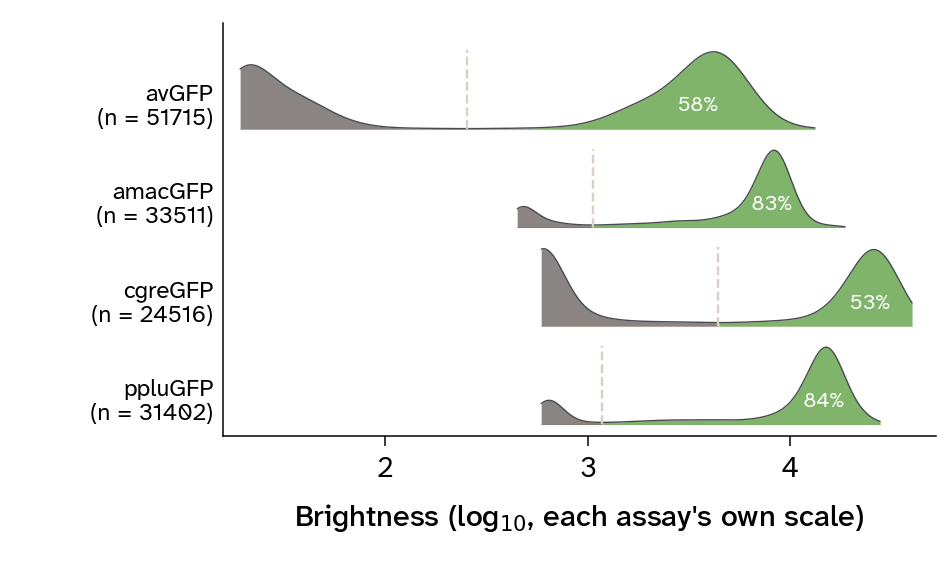

In [4]:
# One density row per scaffold on a shared brightness axis, split at its own cut. The two
# alternative cut rules are computed and printed above but not drawn: three near-coincident rules on
# two of the four rows read as clutter, and the numbers make the point better than the marks did.
# Colour departs from the notebook's Aegean/Amber scheme here for
# one reason: the label being drawn IS green fluorescence, so the functional mass takes an Arcadia
# green and the non-functional pile a dark neutral. Aegean goes back to meaning "the DMS side"
# from Figure 2 onward.
BRIGHT_FILL, BRIGHT_TEXT = GREEN, GREEN_TEXT
DIM_FILL = str(apc.mud)
ROW_H, ROW_GAP = 0.80, 1.02

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.235, right=0.985, bottom=0.235, top=0.96)

for i, sc in enumerate(SCAFFOLDS):
    c = CUTS[sc]
    base = (len(SCAFFOLDS) - 1 - i) * ROW_GAP
    grid = np.linspace(c["x"].min(), c["x"].max(), 400)
    dens = gaussian_kde(c["x"])(grid)
    dens = dens / dens.max() * ROW_H
    dim, bright = grid < c["antimode"], grid >= c["antimode"]
    ax.fill_between(grid[dim], base, base + dens[dim], color=DIM_FILL, alpha=0.75, lw=0, zorder=2)
    ax.fill_between(grid[bright], base, base + dens[bright], color=BRIGHT_FILL, alpha=0.9, lw=0,
                    zorder=2)
    ax.plot(grid, base + dens, color=str(apc.charcoal), lw=0.7, zorder=4)
    ax.plot([c["x"].min(), c["x"].max()], [base] * 2, color=NEUTRAL_SOFT, lw=0.6, zorder=1)
    ax.plot([c["antimode"]] * 2, [base, base + ROW_H * 1.02], color=NEUTRAL_SOFT,
             ls='--', lw=1.2, zorder=5)
    # The one number the row needs, set in white on the functional mass itself: no leader, no
    # value for the cut (the cut is where the fill changes colour, and its number is printed above).
    # At half-column width the functional mode of three of the four scaffolds is only ~40 px across,
    # which fits a percentage and nothing else -- the word "bright" the wide version carried under it
    # ran off the green and became white text on the page, so the caption carries it instead. The
    # label is centred on the width of the peak at its own height rather than on the peak itself,
    # which for a right-skewed mode keeps it clear of the steep flank.
    peak = np.where(bright)[0][np.argmax(dens[bright])]
    y_lab = dens[peak] * 0.30
    lo = hi = peak
    while lo > 0 and dens[lo - 1] >= y_lab:
        lo -= 1
    while hi < len(dens) - 1 and dens[hi + 1] >= y_lab:
        hi += 1
    # Half the panel width means half the pixels per log unit, so the label is set smaller and
    # its centre is clamped inside the axes: three of the four functional modes sit against the
    # right-hand end of their scale, where a centred label would run off the panel.
    ax.annotate(f"{100 * c['bright']:.0f}%", xy=(0.5 * (grid[lo] + grid[hi]), base + y_lab),
                ha="center", va="center", zorder=6,
                **{**NUMBER_NOTE, "fontsize": 11, "color": "white"})

top = (len(SCAFFOLDS) - 1) * ROW_GAP
# "dim" sits in the trough of the top row, the one place on any row with clear ground between the
# non-functional pile and the cut rule.
ax.set_yticks([(len(SCAFFOLDS) - 1 - i) * ROW_GAP for i in range(len(SCAFFOLDS))])
SCAFFOLDS_LABELS = [S+f"\n(n = {CUTS[S]['n']})" for S in SCAFFOLDS]
ax.set_yticklabels(SCAFFOLDS_LABELS,va="bottom",fontsize=12)
ax.set_xlim(1.2, 4.72)   # room at the left for avGFP's variant count, which starts furthest left
ax.set_ylim(-0.12, top + ROW_H + 0.30)
ax.set_xticks([2, 3, 4])      # half the ticks of the wide version: eight labels collide here
ax.set_xlabel("Brightness (log$_{10}$, each assay's own scale)")
apc.mpl.style_plot(ax, monospaced_axes="x")
bare(ax)
ax.tick_params(axis="y", length=0)

fig.savefig(f"{FIGDIR}/brightness_threshold_choice.svg")
fig.savefig(f"{FIGDIR}/brightness_threshold_choice.png", dpi=200)
plt.show()

**Figure 1. Each scaffold's bright/dim cut sits in its own density valley, at a brightness value no
other scaffold shares.** Kernel density of log-brightness for each scaffold's
full processed dataset on a shared axis, each row split at that scaffold's own KDE antimode:
non-functional mass in dark neutral, functional mass in green (the same green Figure 2 gives the
architecture trained on this label), the deployed cut as the full-height
charcoal rule, with the bright fraction it produces set in white on the functional mass; at the left
of each row is that dataset's variant count.

This is the argument for a per-scaffold cut. avGFP's dead pile sits at log10 1.34 and its functional
mode at 3.62, giving a cut at **2.41**; the orthologue assay floors at 2.68-2.81 with functional modes
at 3.92-4.41, giving cuts at **3.03** (amacGFP), **3.64** (cgreGFP) and **3.07** (ppluGFP). Any single
global cut would misclassify a whole scaffold — 2.41 would call essentially every orthologue variant
bright, 3.64 would call most of avGFP dim. Recomputing the antimode reproduces the stored
`brightnessClass` column exactly for all four datasets (58.2 / 83.5 / 52.8 / 83.7% bright), so the
label the sweep trains on is exactly the one this figure draws. The valleys are real minima, not
shoulders: valley density is 0.5-4.4% of peak density.

The exact cut position is not a live worry — the cell above prints the sensitivity: moving a cut
±0.1 log units relabels at most 0.94% of variants (avGFP 0.04%, cgreGFP 0.61%, ppluGFP 0.74%,
amacGFP 0.94%), and ±0.2 units stays under 2.5%. What matters is the *rule*. For avGFP and cgreGFP
the three rules effectively agree (≤0.25% relabelled; their cuts differ by less than 0.07 log units).
For amacGFP and ppluGFP the GMM crossover lands +0.67 and +0.83 log units higher — inside the
functional mode rather than in the valley — relabelling 14.1% and 12.3% of variants and dropping their bright fractions from 83.5% to
69.3% and 83.7% to 71.3%. Those two are the bright-skewed scaffolds (84% bright), i.e. the ones where
a "bright" call carries the least information to begin with; if a later round wants a stricter
functional-brightness label rather than a functional-vs-dead one, those are the two datasets whose
labels would move, and the per-scaffold precision numbers in Section 3's printout are the ones to
re-read afterwards.

## 2. Architecture sweep for the bright/dim classifier

The classifier reads ESM-2 650M per-residue embeddings and predicts one logit for the label
Section 1 defines. The grid is
two backbones — `mlp` (pool only) and `cnn` at depth 1-3 — crossed with six pooling readouts
(`mean`, `max`, `concat`, `concatstd`, `attn`, and the covariance probe `cov`), 24 configurations,
each trained once at seed 0 with BCE-with-logits and `pos_weight` for class imbalance, early-stopped
on validation BCE ([`sweep_classify_parallel.py`](sweep_classify_parallel.py)).

The data is the stratified four-scaffold subsample `sub20k` — 5,000 variants each from avGFP,
amacGFP, cgreGFP and ppluGFP, split per scaffold 70/15/15
([`build_subsample.py`](build_subsample.py)) — so 14,000 train / 3,000 validation / 3,000 test
variants, 69% bright in validation.

Two baselines are pinned alongside the ranking, both fitted on the same 14,000 training variants and
scored on the same 3,000 validation variants:

- **Embedding retrieval**: predict a held-out variant's bright probability as the mean label of its
  *k* nearest training variants in max-pooled ESM-2 space (cosine distance, *k* = 1, 3, 5, 10, 20).
  This is the "does the learned readout beat looking up neighbours" floor.
- **Mutation count**: logistic regression on the number of substitutions from the scaffold's
  wild type plus a scaffold indicator, and nothing else. For DMS brightness this is the baseline
  that matters — brightness falls off steeply with mutational load, so a model can score well by
  counting edits, and any learned readout has to clear that floor before its score means
  anything else.

In [5]:
BACKBONE_LABEL = {"cnn": "CNN", "mlp": "None"}


def load_board(path=f"{SWEEP_DIR}/results.csv"):
    """One row per configuration: architecture/pooling/depth and its val/test metrics."""
    df = pd.read_csv(path).sort_values("val_auroc", ascending=False).reset_index(drop=True)
    df["pretty"] = [f"{BACKBONE_LABEL[a]} ({d}) - {p}" for a, d, p in
                    zip(df["arch"], df["depth"], df["pool"])]
    return df


board = load_board()
DEPLOYED_LABEL = "cnn-max-d2"
rank = int(board.index[board.label == DEPLOYED_LABEL][0]) + 1
best = board.iloc[0]
collapsed = board[board.val_auroc < 0.55]

print(f"{len(board)} configurations | best {best['pretty']} at val AUROC {best.val_auroc:.4f}")
print(f"deployed architecture {DEPLOYED_LABEL} ranks {rank} of {len(board)} "
      f"(val AUROC {float(board.loc[board.label == DEPLOYED_LABEL, 'val_auroc'].iloc[0]):.4f})")
print(f"collapsed to chance ({len(collapsed)}): {', '.join(collapsed.label) or 'none'}")

# The refit that is actually deployed: same architecture, twice the data (sub40k, 10k/scaffold).
import torch  # noqa: E402
_meta = torch.load(DEPLOYED, map_location="cpu", weights_only=False)
REFIT = {k: _meta[k] for k in ("val_auroc", "test_auroc", "val_acc", "test_acc", "n_train",
                               "epoch_best")}
print(f"deployed refit on {REFIT['n_train']:,} train variants: val AUROC {REFIT['val_auroc']:.4f}, "
      f"test AUROC {REFIT['test_auroc']:.4f} @ep{REFIT['epoch_best']}")

24 configurations | best CNN (2) - concatstd at val AUROC 0.9609
deployed architecture cnn-max-d2 ranks 3 of 24 (val AUROC 0.9595)
collapsed to chance (2): cnn-cov-d3, cnn-cov-d2


deployed refit on 28,000 train variants: val AUROC 0.9816, test AUROC 0.9809 @ep34


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

K_SWEEP = [1, 3, 5, 10, 20]
POOLED_NPY = f"{DMS}/sub20k_maxpool.npy"    # analysis cache, git-ignored like the rest of DMS_data/


def sub20k_maxpool(path=POOLED_NPY):
    """Max-pooled ESM-2 embedding per sub20k variant, cached.

    The sweep's own cache is the (20000, 237, 1280) fp16 per-residue array -- 12 GB, more than this
    machine's RAM once anything else is loaded -- so pool it in blocks straight off the memmap and
    keep only the (20000, 1280) result. Max pooling is used because that is the readout the
    deployed model learns on top of; the retrieval floor should see the same summary.
    """
    if os.path.exists(path):
        return np.load(path)
    H = np.load(f"{DMS}/sub20k_esm_residue_fp16.npy", mmap_mode="r")
    Ls = np.load(f"{DMS}/sub20k_esm_residue_len.npy").astype(int)
    out = np.empty((len(H), H.shape[2]), np.float32)
    for i in range(0, len(H), 200):
        blk = np.asarray(H[i:i + 200]).astype(np.float32)
        for j in range(len(blk)):
            out[i + j] = blk[j, :Ls[i + j]].max(0)
    np.save(path, out)
    return out


def mutation_load(rows, seq_col="mutatedSequence"):
    """Substitutions from each scaffold's wild type.

    The processed DMS tables carry only the mutated full-length sequence, so the wild type is
    recovered as the scaffold's per-position consensus: these libraries average ~3 substitutions
    in 235-239 positions, so the modal residue at every position is the parent by a wide margin.
    """
    n_mut = np.zeros(len(rows), int)
    for _, g in rows.groupby("scaffold"):
        arr = np.array([list(s) for s in g[seq_col]])
        wt = np.array([pd.Series(arr[:, j]).mode()[0] for j in range(arr.shape[1])])
        n_mut[g.index.to_numpy()] = (arr != wt[None, :]).sum(1)
    return n_mut


rows20 = pd.read_csv(f"{DMS}/sub20k_sequences.csv")
y20 = rows20.label.to_numpy()
tr20 = np.where(rows20.split == "train")[0]
va20 = np.where(rows20.split == "val")[0]
X20 = sub20k_maxpool()
NMUT20 = mutation_load(rows20)

nulls = {}
for k in K_SWEEP:
    nn = NearestNeighbors(n_neighbors=k, metric="cosine").fit(X20[tr20])
    idx = nn.kneighbors(X20[va20], return_distance=False)
    nulls[f"NN k={k}"] = roc_auc_score(y20[va20], y20[tr20][idx].mean(1))

Xn = np.column_stack([NMUT20, pd.get_dummies(rows20.scaffold).to_numpy().astype(float)])
lr = LogisticRegression(max_iter=1000).fit(Xn[tr20], y20[tr20])
nulls["Edit count"] = roc_auc_score(y20[va20], lr.predict_proba(Xn[va20])[:, 1])

best_null = max(nulls.values())
for lab, v in nulls.items():
    print(f"  {lab:10} val AUROC {v:.4f}")
print(f"best baseline {best_null:.4f} | configurations above it: "
      f"{int((board.val_auroc > best_null).sum())} of {len(board)}")
print(f"train/val bright prevalence {y20[tr20].mean():.3f} / {y20[va20].mean():.3f}; "
      f"median edit load {np.median(NMUT20):.0f} substitutions")

  NN k=1     val AUROC 0.6444
  NN k=3     val AUROC 0.7161
  NN k=5     val AUROC 0.7409
  NN k=10    val AUROC 0.7630
  NN k=20    val AUROC 0.7739
  Edit count val AUROC 0.7690
best baseline 0.7739 | configurations above it: 18 of 24
train/val bright prevalence 0.697 / 0.690; median edit load 3 substitutions


In [7]:
# Is the top of the leaderboard a real ordering? Only 3,000 validation variants separate the top
# configurations, so their logits are rescored here and the AUROC differences bootstrapped over
# variants (paired: the same resampled variants for every configuration). This is what makes the
# selection statement in the caption an honest one rather than "we took the argmax".
from fpdesign import peak_models as pm  # noqa: E402

TOP5 = board.label.head(5).tolist()
BOOT_NPZ = f"{SWEEP_DIR}/val_logits_top5.npz"
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def val_logits(labels=TOP5, path=BOOT_NPZ):
    """Validation logits per configuration, cached. Reads only the 3,000 validation rows."""
    if os.path.exists(path):
        z = np.load(path)
        return {lab: z[lab] for lab in labels}
    H = np.load(f"{DMS}/sub20k_esm_residue_fp16.npy", mmap_mode="r")
    Ls = np.load(f"{DMS}/sub20k_esm_residue_len.npy").astype(int)
    ar = torch.arange(H.shape[1])
    out = {}
    for lab in labels:
        net, _ = pm.load_model(f"{SWEEP_DIR}/{lab}_s0.pt", dev, out=1)
        net.eval()
        chunks = []
        with torch.no_grad():
            for i in range(0, len(va20), 128):
                b = va20[i:i + 128]
                Hb = torch.from_numpy(np.asarray(H[b])).float().to(dev)
                mk = (ar.unsqueeze(0) < torch.tensor(Ls[b]).unsqueeze(1)).to(dev)
                chunks.append(net(Hb, mk).cpu().numpy().ravel())
        out[lab] = np.concatenate(chunks)
    np.savez(path, **out)
    return out


VL = val_logits()
yv = y20[va20]
rng = np.random.default_rng(RNG_SEED)
BOOT = 2000
draws = rng.integers(0, len(yv), (BOOT, len(yv)))
boot = {lab: np.array([roc_auc_score(yv[d], VL[lab][d]) for d in draws]) for lab in TOP5}
point = {lab: roc_auc_score(yv, VL[lab]) for lab in TOP5}

for lab in TOP5:
    print(f"  {lab:18} AUROC {point[lab]:.4f}  bootstrap 95% "
          f"[{np.percentile(boot[lab], 2.5):.4f}, {np.percentile(boot[lab], 97.5):.4f}]")
print()
for lab in TOP5:
    if lab == DEPLOYED_LABEL:
        continue
    d = boot[lab] - boot[DEPLOYED_LABEL]
    print(f"  {lab:18} minus {DEPLOYED_LABEL}: {point[lab] - point[DEPLOYED_LABEL]:+.4f}  "
          f"95% [{np.percentile(d, 2.5):+.4f}, {np.percentile(d, 97.5):+.4f}]  "
          f"P(better) = {np.mean(d > 0):.2f}")

  cnn-concatstd-d2   AUROC 0.9609  bootstrap 95% [0.9536, 0.9682]
  cnn-concat-d2      AUROC 0.9601  bootstrap 95% [0.9525, 0.9679]
  cnn-max-d2         AUROC 0.9595  bootstrap 95% [0.9517, 0.9670]
  cnn-max-d1         AUROC 0.9532  bootstrap 95% [0.9450, 0.9611]
  cnn-concatstd-d1   AUROC 0.9489  bootstrap 95% [0.9401, 0.9575]

  cnn-concatstd-d2   minus cnn-max-d2: +0.0014  95% [-0.0057, +0.0086]  P(better) = 0.66
  cnn-concat-d2      minus cnn-max-d2: +0.0006  95% [-0.0067, +0.0080]  P(better) = 0.59
  cnn-max-d1         minus cnn-max-d2: -0.0064  95% [-0.0140, +0.0015]  P(better) = 0.06
  cnn-concatstd-d1   minus cnn-max-d2: -0.0106  95% [-0.0188, -0.0018]  P(better) = 0.01


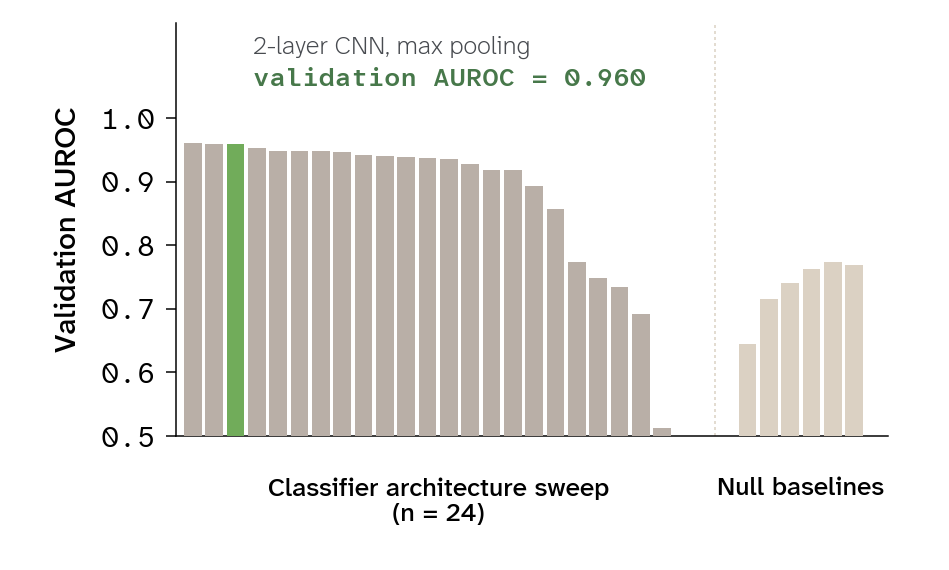

In [8]:
# The deployed architecture in GREEN; every other configuration and every baseline recedes into
# neutral tones, per the guide's "one series emphasized, the rest recede" pattern. The y-axis starts
# at 0.5 because that is the floor of the metric -- a bar drawn from 0 to chance carries no
# information -- which is also why the two collapsed configurations have no visible bar.
ranked = board.reset_index(drop=True)
null_items = list(nulls.items())
GAP = 2.0
x_cfg = np.arange(len(ranked))
x_null = np.arange(len(null_items)) + len(ranked) + GAP
hi = int(ranked.index[ranked.label == DEPLOYED_LABEL][0])
bar_color = [GREEN if i == hi else NEUTRAL for i in range(len(ranked))]
FLOOR = 0.5

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.185, right=0.935, bottom=0.235, top=0.96)

ax.bar(x_cfg, ranked.val_auroc - FLOOR, bottom=FLOOR, color=bar_color, width=0.82,
       edgecolor="none", zorder=3)
ax.bar(x_null, [v - FLOOR for _, v in null_items], bottom=FLOOR, color=NEUTRAL_SOFT, width=0.82,
       edgecolor="none", zorder=3)
ax.axvline(len(ranked) - 0.5 + GAP / 2, ls=(0, (2, 2)), color=NEUTRAL_SOFT, lw=0.75, zorder=2)

# The callout is the configuration that was selected and the number it was selected on: its own
# validation AUROC, the height of the green bar. The deployed checkpoint is this architecture
# refit on twice the data -- a different number, on a different split, which the caption carries
# rather than a label sitting next to a bar it does not describe.

deployed_auroc = float(ranked.loc[hi, "val_auroc"])
ax.annotate("2-layer CNN, max pooling", xy=(hi + 0.8, 1.112), xycoords="data",
            ha="left", va="center", **{**ANNOTATION, "fontsize": 13})
ax.annotate(f"validation AUROC = {deployed_auroc:.3f}", xy=(hi + 0.8, 1.062), xycoords="data",
            ha="left", va="center",
            **{**NUMBER_NOTE, "fontsize": 13, "fontweight": "semibold", "color": GREEN_TEXT})

ax.set_xticks([])
ax.set_xlim(-0.8, x_null.max() + 1.6)
ax.set_ylim(FLOOR, 1.15)
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_ylabel("Validation AUROC")

# At this width the two x-axis group labels are what sets the bottom margin, so they run at
# 13 pt: the wide version's 15 pt made the longer one overrun its own group of bars.
group_style = {**label_style, "fontsize": 13}
ax.text(x_cfg.mean(), -0.10, "Classifier architecture sweep\n(n = 24)",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **group_style)
ax.text(x_null.mean(), -0.10, "Null baselines",
        transform=ax.get_xaxis_transform(), ha="center", va="top", **group_style)

apc.mpl.style_plot(ax, monospaced_axes="y")
bare(ax)
ax.tick_params(axis="x", length=0)

fig.savefig(f"{FIGDIR}/brightness_sweep_auroc.svg")
fig.savefig(f"{FIGDIR}/brightness_sweep_auroc.png", dpi=200)
plt.show()

**Figure 2. The pooling readout barely matters at the top of the sweep, so the deployed
architecture was picked from a three-way tie — but every learned configuration that trained at all
clears the retrieval and edit-count baselines by a wide margin.** Validation AUROC for all 24
backbone x pooling x depth configurations of the bright/dim classifier (single seed, per-scaffold
70/15/15 split of the 20,000-variant four-scaffold subsample), ranked left to right, against
embedding-retrieval baselines (cosine *k*-NN over max-pooled ESM-2, *k* = 1-20) and a logistic
regression on edit count plus scaffold identity. The deployed architecture, CNN (2) - max, is in
green -- the colour this notebook reserves for the bright class and for the model that predicts it;
the short rule above it is the same architecture refit on the 40,000-variant subsample,
which is the checkpoint the campaign actually loads. The axis starts at 0.5 because that is chance
for AUROC.

`cnn-max-d2` ranks **third** on this leaderboard, behind `cnn-concatstd-d2` (0.9609) and
`cnn-concat-d2` (0.9601) at 0.9595 — and the paired bootstrap over the 3,000 validation variants
says that ordering is not real: the AUROC difference to either configuration above it has a 95%
interval straddling zero ([-0.006, +0.009] and [-0.007, +0.008]), with P(better) of 0.66 and 0.59.
The two configurations *below* it separate more cleanly (`cnn-max-d1` at P = 0.06,
`cnn-concatstd-d1` at P = 0.01), so what the sweep establishes is a top group of three, not a
winner. Within that group the choice went to max pooling because it is the cheapest readout of the
three (one vector per residue channel, no concatenated statistics) and because it is the same
readout the peak surrogate uses, so a design run holds one pooling convention end to end.

Depth and pooling behave as they do on the peak sweeps: CNNs beat the pool-only MLPs everywhere
(0.918-0.961 vs 0.691-0.893), depth 2 is the sweet spot, and the covariance probe is the one
unstable member of the grid — competitive at depth 1 (0.947) but the *only* thing in the sweep that
fails to train at all, with `cnn-cov-d2` and `cnn-cov-d3` both collapsing to a single class
(AUROC 0.500 and 0.513, F1 = 0.000, no epoch survived early stopping). Doubling the training data
for the refit moves validation AUROC from 0.960 to 0.982 and accuracy from 0.903 to 0.943, which is
the only reason a second training run was worth doing.

The baselines are worth reading as a pair. Retrieval over the same embedding tops out at 0.774
(*k* = 20) and edit count plus scaffold reaches 0.769 — so ESM-2 neighbourhoods and "how many
mutations does it carry" are about equally informative, and the learned readout adds ~0.19 AUROC on
top of either. Eighteen of 24 configurations clear the strongest baseline; the six that do not are
the two collapsed covariance fits and the four weakest pool-only MLPs (`mlp-mean` 0.773 through
`mlp-concatstd` 0.691), which is a statement about pooling without a convolution, not about the
architecture family that got deployed — every CNN in the grid that trained at all beats every
baseline.

## 3. What the campaign asks of this classifier, and which metrics answer it

Figure 2's numbers are the sweep's own: AUROC over a held-out sample of the same DMS libraries the
model trained on. That is the right metric for *choosing an architecture* and the wrong one for
*deciding how much to trust a shortlist*, because the campaign's question differs from the sweep's
in four specific ways. This notebook answers the first; the other three are named here because they
are what makes the first one necessary, not because they are computed below.

| The campaign does this | So the metric should be |
|---|---|
| Thresholds the logit — `logit > 0` reported as `is_bright`, `logit > 0.5` to enter a shortlist pool — and never ranks DMS variants | **Precision at those two thresholds** (printed below) and **where they sit on the ROC**, not AUROC over the whole score range — Section 4 |
| Admits a design when its ESM-2 max-pool NN distance to the 40k DMS cloud is inside the cloud's own 99th percentile | **Precision inside that same distance stratum**, which is the sparsest corner of the training distribution |
| Applies **one** threshold everywhere, to designs that sit in the sparsest strata | **TPR and FPR per stratum** (a ROC per stratum), which separates the classifier degrading from the population getting harder |
| Spends 10 wet-lab wells per strategy on designs whose true bright rate nobody knows | **Expected yield as a function of the assumed prior**, driven by the measured likelihood ratio rather than by DMS prevalence |

Two things follow from the table that are worth stating before any of the figures.

**Aggregate AUROC and accuracy are dominated by variants the campaign will never see.** Two thirds
of held-out variants are scored with |logit| > 4 — the model is certain, and it is right — while
the slab between the campaign's two thresholds (`logit` 0 to 0.5) holds 1.1% of them. A metric
averaged over the whole test set is therefore mostly a report on easy variants.

**Precision, not accuracy, is the currency.** The campaign discards candidates by the thousand
(2,091 DMS-guided and 5,448 MSA-guided designs, of which 3.5% and 24.5% clear the ID-and-bright
gate), so
recall costs nothing: a missed bright design is one of many, while a shortlisted dim design is a
wasted well. Every number below that could be quoted either way is quoted as precision.

Section 4 reads the deployed checkpoint's per-variant held-out predictions from
[`figures/nn_distance_accuracy_per_row.csv`](figures/nn_distance_accuracy_per_row.csv)
(written by [`nn_distance_accuracy.py`](nn_distance_accuracy.py), which scores all 40,000 sub40k
variants with `trained_models/cnn_max_d2_40k/cnn-max-d2_s0.pt`), and use the **test** split only —
1,500 variants per scaffold, never touched by training or early stopping.

Every number binned by distance from the DMS cloud is the exception — Figure 3's inset. Those
strata are slices of the distance axis a hundred times thinner than the
split can support, so they are measured on **every** processed variant the checkpoint never learned
from — 97,499 of them, the whole four-scaffold corpus minus both subsamples' train and validation
rows. The second cell below scores that pool once and caches it, and defines the strata every one
of those figures bins by; it needs no new embeddings, and it says how.

In [9]:
# The deployed model's held-out predictions, plus the two axes the campaign cares about: how far a
# variant sits from its wild type (edit load) and how far it sits from the DMS cloud (NN distance,
# already computed per row by nn_distance_accuracy.py in the same z-scored max-pool space the
# campaign's in-distribution gate uses).
pr = pd.read_csv(PER_ROW)
rows40 = pd.read_csv(f"{DMS}/sub40k_sequences.csv")
assert (pr.scaffold.values == rows40.scaffold.values).all() and (pr.y.values == rows40.label.values).all(), \
    "nn_distance_accuracy_per_row.csv is not row-aligned with sub40k_sequences.csv -- rerun the script"

held = pr.assign(n_mut=mutation_load(rows40), logit=np.log(pr.prob / (1 - pr.prob)))
te = held[held.split == "test"].reset_index(drop=True)

# The campaign's two thresholds, from make_shortlist_case.py: the model's own decision boundary and
# the stricter bar a design must clear to enter a shortlist pool.
THR_MODEL, THR_SHORTLIST = 0.0, 0.5


def gate(g, thr=THR_SHORTLIST):
    """What the campaign's gate does to a set of variants, in the campaign's own terms."""
    keep = g.logit > thr
    y = g.y == 1
    tp, fp = int((keep & y).sum()), int((keep & ~y).sum())
    tpr = (keep & y).sum() / max(y.sum(), 1)
    fpr = (keep & ~y).sum() / max((~y).sum(), 1)
    return dict(n=len(g), prevalence=y.mean(), kept=keep.mean(), n_kept=tp + fp,
                precision=tp / max(tp + fp, 1), recall=tpr, fpr=fpr,
                lr_plus=tpr / max(fpr, 1e-9),
                auroc=roc_auc_score(g.y, g.prob) if 0 < g.y.sum() < len(g) else np.nan)


# The band the campaign actually operates in: the brightness logits of the designs that were
# shortlisted for the wet lab, read back out of the shortlist workbooks rather than assumed. Only
# the brightness-guided strategies are gated on the classifier, so only their workbooks carry a
# logit that was used as a filter. The DMS-guide pair was retired with the folder restructure
# (15f9048) and no longer exists, so the MSA guide is the only gated strategy with a shortlist.
SHORTLIST_FILES = [f"{CAMP}/shortlists/shortlist_{t}_MSA-guide.xlsx"
                   for t in ("EBFP", "mOrange")]
shortlisted = pd.concat([pd.read_excel(f) for f in SHORTLIST_FILES], ignore_index=True)
shortlisted = shortlisted[shortlisted.role == "design"]
SHORT_LOGIT = shortlisted.bright_logit.astype(float).to_numpy()
SHORT_LO, SHORT_HI = float(SHORT_LOGIT.min()), float(SHORT_LOGIT.max())
SHORT_MUT = shortlisted.n_mut_vs_EGFP.astype(float).to_numpy()

print(f"test split: {len(te):,} variants, {te.y.mean():.1%} bright, "
      f"AUROC {roc_auc_score(te.y, te.prob):.4f}, accuracy at logit>0 "
      f"{((te.logit > 0).astype(int) == te.y).mean():.3f}")
print(f"|logit| > 4: {(te.logit.abs() > 4).mean():.1%} of test variants | "
      f"logit in [0, 0.5]: {((te.logit >= 0) & (te.logit <= 0.5)).mean():.1%}")
print()
for thr in (THR_MODEL, THR_SHORTLIST):
    m = gate(te, thr)
    print(f"logit > {thr:+.1f} (p > {1 / (1 + np.exp(-thr)):.3f}): keeps {m['kept']:.1%} of variants, "
          f"precision {m['precision']:.4f}, recall {m['recall']:.3f}, LR+ {m['lr_plus']:.1f}")
print()
print(f"{'scaffold':10} {'n':>5} {'bright':>7} {'AUROC':>7} {'prec@0':>8} {'prec@0.5':>9}")
for s, g in te.groupby("scaffold"):
    print(f"{s:10} {len(g):5d} {g.y.mean():7.3f} {gate(g)['auroc']:7.4f} "
          f"{gate(g, THR_MODEL)['precision']:8.4f} {gate(g, THR_SHORTLIST)['precision']:9.4f}")
print()
tr40 = held[held.split == "train"]
pw = (1 - tr40.y.mean()) / tr40.y.mean()
print(f"training pos_weight = (1-prev)/prev = {pw:.3f}, i.e. every logit is shifted by "
      f"log(pos_weight) = {np.log(pw):+.3f} relative to a prevalence-calibrated model; "
      f"mean predicted probability {te.prob.mean():.4f} vs observed prevalence {te.y.mean():.4f}")
print()
print(f"{len(SHORT_LOGIT)} shortlisted designs: logit {SHORT_LO:.2f} to {SHORT_HI:.2f} "
      f"(median {np.median(SHORT_LOGIT):.2f}), {int(SHORT_MUT.min())}-{int(SHORT_MUT.max())} "
      f"substitutions from EGFP (median {np.median(SHORT_MUT):.0f})")

test split: 6,000 variants, 69.8% bright, AUROC 0.9809, accuracy at logit>0 0.938
|logit| > 4: 66.6% of test variants | logit in [0, 0.5]: 1.1%

logit > +0.0 (p > 0.500): keeps 68.2% of variants, precision 0.9660, recall 0.945, LR+ 12.3
logit > +0.5 (p > 0.622): keeps 67.0% of variants, precision 0.9709, recall 0.933, LR+ 14.5

scaffold       n  bright   AUROC   prec@0  prec@0.5
amacGFP     1500   0.842  0.9741   0.9692    0.9721
avGFP       1500   0.600  0.9862   0.9592    0.9677
cgreGFP     1500   0.511  0.9721   0.9553    0.9578
ppluGFP     1500   0.837  0.9820   0.9736    0.9790

training pos_weight = (1-prev)/prev = 0.435, i.e. every logit is shifted by log(pos_weight) = -0.832 relative to a prevalence-calibrated model; mean predicted probability 0.6763 vs observed prevalence 0.6975

20 shortlisted designs: logit 0.63 to 4.22 (median 1.74), 6-14 substitutions from EGFP (median 10)


In [10]:
# Every processed DMS variant the deployed checkpoint never learned from, scored once and cached.
#
# Why a second held-out population at all: the one distance-conditioned number below -- the Figure 3
# inset -- is measured inside strata that
# hold about 1% of the reference cloud each. On the 6,000-row test split that left 51 variants in
# the 98-99 band, of which 11 were called bright, i.e. a precision with a +/-20-point interval. So
# those sections evaluate on the whole processed corpus minus everything the model was fitted or
# selected on: 141,144 variants across the four scaffolds, minus every row in the train or validation
# split of either subsample -- sub40k, which trained the deployed checkpoint, and sub20k, which chose
# its architecture. The remainder includes both subsamples' test rows and the ~100k variants that were
# never sampled into either.
#
# Nothing has to be re-embedded: the per-residue ESM-2 caches for both source tables already exist
# (31 GB + 54 GB), so the pass streams them block by block, runs the classifier head, and max-pools
# the same vectors the in-distribution test needs. It is I/O-bound at roughly ten minutes, so its
# output -- label, logit, distance and edit load per variant -- is cached in DMS_data/ under a
# signature naming the checkpoint and the exclusion set, and rebuilt only if either changes.
from concurrent.futures import ThreadPoolExecutor  # noqa: E402
import hashlib  # noqa: E402
import time  # noqa: E402

HELDOUT_NPZ = f"{DMS}/heldout_scored.npz"
POOL_SOURCES = [("avgfp_dms_sequences.csv", "esm_residue_fp16.npy", "esm_residue_len.npy"),
                ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy",
                 "ortho_gfp_dms_esm_residue_len.npy")]
POOL_COLS = ("scaffold", "y", "logit", "nn_dist", "n_mut", "src", "src_row")

# The in-distribution reference: the sub40k max-pool cloud, z-scoring and cut the campaign uses.
# Defined here because both this section's held-out pool and the design distances below need it.
ref = np.load(f"{DMS}/sub40k_maxpool.npz", allow_pickle=True)
MP = ref["mp"]
mu, sd = MP.mean(0), MP.std(0) + 1e-6
Zref = torch.as_tensor((MP - mu) / sd, dtype=torch.float32, device=dev)


def _fitted_on():
    """{(src, src_row)} for every row either subsample used to fit or to select -- what to exclude."""
    ex = set()
    for stem in ("sub20k", "sub40k"):
        df = pd.read_csv(f"{DMS}/{stem}_sequences.csv")
        m = df.split.isin(("train", "val"))
        ex |= set(zip(df.src[m], df.src_row[m]))
    return ex


def score_heldout_pool(path=HELDOUT_NPZ, block=1024):
    """Score every never-fitted DMS variant with the deployed checkpoint; cached to `path`.

    Returns a frame with one row per variant: scaffold, label, logit, 1-NN distance to the 40k
    reference cloud (self-excluded for the 40k rows that are themselves in it) and edit load.
    """
    excluded = _fitted_on()
    # Content-addressed on the checkpoint's bytes, not its filename. The deployed head is tracked
    # in git under a different basename than the training run wrote, so keying on the name
    # invalidated this cache the moment the path changed -- forcing an 85 GB rescore for a model
    # that had not changed at all. A hash survives any rename and still invalidates correctly if
    # the weights are ever retrained.
    ckpt_id = hashlib.sha256(open(DEPLOYED, "rb").read()).hexdigest()[:12]
    signature = f"{ckpt_id}|{len(excluded)}|sub40k_maxpool"
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        if str(z["signature"]) == signature:
            print(f"loaded cached scores for {len(z['y']):,} held-out variants ({path})")
            return pd.DataFrame({c: z[c] for c in POOL_COLS})
        print("cache signature does not match the current checkpoint/exclusion set -- rescoring")

    net, _ = pm.load_model(DEPLOYED, dev, out=1)
    net.eval()
    # Row of the reference cloud a variant occupies, if any, so it can be excluded from its own
    # nearest-neighbour search (the cloud IS sub40k, so the row map below is exact).
    s40 = pd.read_csv(f"{DMS}/sub40k_sequences.csv")
    cloud_row = {(a, b): i for i, (a, b) in enumerate(zip(s40.src, s40.src_row))}

    frames, t0 = [], time.time()
    for csv_name, emb_name, len_name in POOL_SOURCES:
        table = pd.read_csv(f"{DMS}/{csv_name}")
        table["n_mut"] = mutation_load(table)
        H = np.load(f"{DMS}/{emb_name}", mmap_mode="r")
        Ls = np.load(f"{DMS}/{len_name}").astype(int)
        assert len(H) == len(table), f"{emb_name} is not row-aligned with {csv_name}"
        rows = np.array([i for i in range(len(table)) if (emb_name, i) not in excluded])
        ar = torch.arange(H.shape[1], device=dev)
        starts = list(range(0, len(rows), block))
        print(f"{csv_name}: {len(rows):,} of {len(table):,} rows held out, "
              f"{len(rows) * H.shape[1] * H.shape[2] * 2 / 1e9:.0f} GB to stream", flush=True)

        def read(k):
            idx = rows[starts[k]:starts[k] + block]
            return idx, np.array(H[idx])

        logits, dists = [], []
        with ThreadPoolExecutor(1) as pool_io, torch.no_grad():
            future = pool_io.submit(read, 0)
            for k in range(len(starts)):
                idx, arr = future.result()
                if k + 1 < len(starts):
                    future = pool_io.submit(read, k + 1)          # read ahead while the GPU works
                Hb = torch.from_numpy(arr).to(dev).float()
                mk = ar.unsqueeze(0) < torch.as_tensor(Ls[idx], device=dev).unsqueeze(1)
                logits.append(net(Hb, mk).float().cpu().numpy().ravel())
                E = (pm.masked_pool(Hb, mk, "max").float()
                     - torch.as_tensor(mu, dtype=torch.float32, device=dev)) \
                    / torch.as_tensor(sd, dtype=torch.float32, device=dev)
                D = torch.cdist(E, Zref)
                for local, r in enumerate(idx):                   # a variant is not its own neighbour
                    ci = cloud_row.get((emb_name, int(r)))
                    if ci is not None:
                        D[local, ci] = float("inf")
                dists.append(D.min(dim=1).values.cpu().numpy())
                if k % 20 == 0 or k == len(starts) - 1:
                    done = min(starts[k] + block, len(rows))
                    print(f"  {done:>7,}/{len(rows):,}  {time.time() - t0:6.0f}s", flush=True)
        sub = table.iloc[rows]
        frames.append(pd.DataFrame(dict(
            scaffold=sub.scaffold.to_numpy(), y=(sub.brightnessClass == "bright").astype(int).to_numpy(),
            logit=np.concatenate(logits), nn_dist=np.concatenate(dists),
            n_mut=sub.n_mut.to_numpy(), src=emb_name, src_row=rows)))

    out = pd.concat(frames, ignore_index=True)
    np.savez_compressed(path, signature=np.array(signature), **{c: out[c].to_numpy() for c in POOL_COLS})
    print(f"scored {len(out):,} held-out variants in {(time.time() - t0) / 60:.1f} min -> {path}")
    return out


pool = score_heldout_pool()
pool["prob"] = 1.0 / (1.0 + np.exp(-pool.logit))     # `gate()` reports AUROC off the probability
print(f"\nheld-out pool: {len(pool):,} variants ({len(pool) / 141144:.0%} of the processed corpus), "
      f"{pool.y.mean():.1%} bright")
print(pool.groupby("scaffold").agg(n=("y", "size"), bright=("y", "mean"),
                                   median_dist=("nn_dist", "median")).round(3).to_string())
# The strata the Figure 3 inset uses: percentiles of the REFERENCE CLOUD's own
# self-neighbour distances -- the campaign's statistic, unchanged.
# The last bin is open-ended: a held-out variant can sit further out than any of the cloud's 40k rows.
PCTS = [0, 50, 90, 95, 98, 99, 100]
EDGES = np.percentile(held.nn_dist, PCTS)
EDGES[-1] = np.inf
STRAT_LABELS = [f"{PCTS[i]}+" if not np.isfinite(EDGES[i + 1]) else f"{PCTS[i]}-{PCTS[i + 1]}"
                for i in range(len(PCTS) - 1)]
STRAT_C = [apc.gradients.blues.to_mpl_cmap()(v)          # apc gradients run dark -> light
           for v in np.linspace(0.78, 0.0, len(STRAT_LABELS))]

print("\nagainst the 6,000-row test split the other sections use:")
print(f"  pooled AUROC {roc_auc_score(pool.y, pool.logit):.4f} vs test-split AUROC "
      f"{roc_auc_score(te.y, te.prob):.4f}; precision at logit>0.5 "
      f"{gate(pool, THR_SHORTLIST)['precision']:.4f} vs {gate(te, THR_SHORTLIST)['precision']:.4f}")

loaded cached scores for 97,499 held-out variants (DMS_data/heldout_scored.npz)

held-out pool: 97,499 variants (69% of the processed corpus), 68.2% bright
              n  bright  median_dist
scaffold                            
amacGFP   21853   0.834       12.536
avGFP     42623   0.582       16.816
cgreGFP   13197   0.523       11.652
ppluGFP   19826   0.836       12.034

against the 6,000-row test split the other sections use:
  pooled AUROC 0.9837 vs test-split AUROC 0.9809; precision at logit>0.5 0.9706 vs 0.9709


## 4. Metric 1 — the two thresholds in ROC space, and the multiplier they buy

Precision at a fixed threshold — 96.6% at the model boundary, 97.1% at the shortlist bar, both
printed above — is what a wet-lab slot cares about, and it is also what makes those numbers
untransportable: precision depends on the population's bright rate, and the design pool's is unknown.
The ROC is the same pair of thresholds with the prevalence divided out — true-positive rate against
false-positive rate — so populations with different bright rates can be compared on it directly,
and the campaign's two thresholds become two points on a curve.

The quantity to read off a ROC here is not the area. It is the **slope of the ray from the origin
through an operating point**, which is the positive likelihood ratio LR+ = TPR / FPR — the factor the
classifier multiplies the odds of "bright" by when it says bright, and the one number that survives
the move from DMS variants to designs. The curve
is the pooled held-out test split; the design-matched stratum of variants carrying at least five
substitutions is computed alongside it and printed, since its likelihood ratio is the one a design
campaign should quote, but it is not drawn — its curve lies on top of the pooled one, and what differs between
them is a number rather than a shape.

One thing an aggregate ROC cannot say is whether that discrimination survives away from the DMS
cloud, which is where the designs are. The inset answers it in one number per stratum, on the
never-fitted pool of Section 3.

In [11]:
from sklearn.metrics import roc_curve  # noqa: E402

# Both populations are computed and printed -- they are the two likelihood ratios a design campaign
# would quote -- but only the pooled one is drawn: the >= 5-substitution curve sits on top of it (the areas
# differ by 0.003) and the quantity that separates them, LR+, is not visible as a separation.
ROC_POPS = [("All held-out variants", te, NEUTRAL),
            ("Variants >= 5 substitutions", te[te.n_mut >= 5], HIGHLIGHT)]
DRAWN = "All held-out variants"
# The campaign's own bar gets the larger marker; the model boundary is the smaller one.
THR_MARKER = {THR_MODEL: "o", THR_SHORTLIST: "^"}
THR_SIZE = {THR_MODEL: 34, THR_SHORTLIST: 130}

ROC = {}
for name, g, color in ROC_POPS:
    fpr, tpr, _ = roc_curve(g.y, g.prob)
    ROC[name] = dict(fpr=fpr, tpr=tpr, auroc=roc_auc_score(g.y, g.prob), color=color,
                     points={t: gate(g, t) for t in (THR_MODEL, THR_SHORTLIST)}, n=len(g),
                     prevalence=float(g.y.mean()))

for name, r in ROC.items():
    print(f"{name:28} n={r['n']:5d} bright {r['prevalence']:.3f} AUROC {r['auroc']:.4f}")
    for t, m in r["points"].items():
        print(f"{'':28}   logit > {t:+.1f}: TPR {m['recall']:.4f}  FPR {m['fpr']:.4f}  "
              f"LR+ {m['lr_plus']:5.1f}  precision {m['precision']:.4f}")
lo, hi = [ROC[n]["points"][THR_SHORTLIST]["lr_plus"] for n, _, _ in ROC_POPS]
d_auroc = abs(ROC[ROC_POPS[0][0]]["auroc"] - ROC[ROC_POPS[1][0]]["auroc"])
print(f"\nAUROC differs by {d_auroc:.4f} between the two populations; LR+ at the shortlist bar "
      f"differs by {hi / lo:.1f}x ({lo:.1f} -> {hi:.1f})")

# The inset: the drawn curve's own area, and then the same classifier's AUROC inside each distance
# stratum on the never-fitted pool of Section 3 -- the one-number-per-stratum version, put next to
# the aggregate it qualifies. The first
# entry is the unstratified test split -- the curve in the panel -- so the inset says what the
# aggregate is before it says what distance does to it.
r_all = ROC[DRAWN]          # the curve the panel draws; its area is the inset's first bar
STRAT_AUROC = []
for i, lab in enumerate(STRAT_LABELS):
    g = pool[(pool.nn_dist >= EDGES[i]) & (pool.nn_dist < EDGES[i + 1])]
    STRAT_AUROC.append(dict(label=lab, auroc=roc_auc_score(g.y, g.logit), n=len(g),
                            prevalence=float(g.y.mean())))
ALL_AUROC = dict(label="All", auroc=r_all["auroc"], n=r_all["n"], prevalence=r_all["prevalence"])
INSET_BARS = [ALL_AUROC] + STRAT_AUROC
print("\nAUROC unstratified (the drawn test-split curve) and by cloud-distance stratum on the")
print("97,499 never-fitted variants, by distance stratum:")
print("  " + "  ".join(f"{s['label']:>7}" for s in INSET_BARS))
print("  " + "  ".join(f"{s['auroc']:7.3f}" for s in INSET_BARS))
print("  " + "  ".join(f"{s['n']:7,d}" for s in INSET_BARS) + "   variants")
print(f"  the wide pool unstratified is {roc_auc_score(pool.y, pool.logit):.3f}, so the "
      "leftmost bar is not an easier population than the six")

All held-out variants        n= 6000 bright 0.698 AUROC 0.9809
                               logit > +0.0: TPR 0.9446  FPR 0.0766  LR+  12.3  precision 0.9660
                               logit > +0.5: TPR 0.9333  FPR 0.0645  LR+  14.5  precision 0.9709
Variants >= 5 substitutions  n=  914 bright 0.299 AUROC 0.9784
                               logit > +0.0: TPR 0.8608  FPR 0.0343  LR+  25.1  precision 0.9144
                               logit > +0.5: TPR 0.8498  FPR 0.0265  LR+  32.0  precision 0.9317

AUROC differs by 0.0025 between the two populations; LR+ at the shortlist bar differs by 2.2x (14.5 -> 32.0)

AUROC unstratified (the drawn test-split curve) and by cloud-distance stratum on the
97,499 never-fitted variants, by distance stratum:
      All     0-50    50-90    90-95    95-98    98-99      99+
    0.981    0.982    0.978    0.972    0.970    0.951    0.958
    6,000   42,546   41,912    6,364    4,003    1,438    1,234   variants
  the wide pool unstratified is 0.98

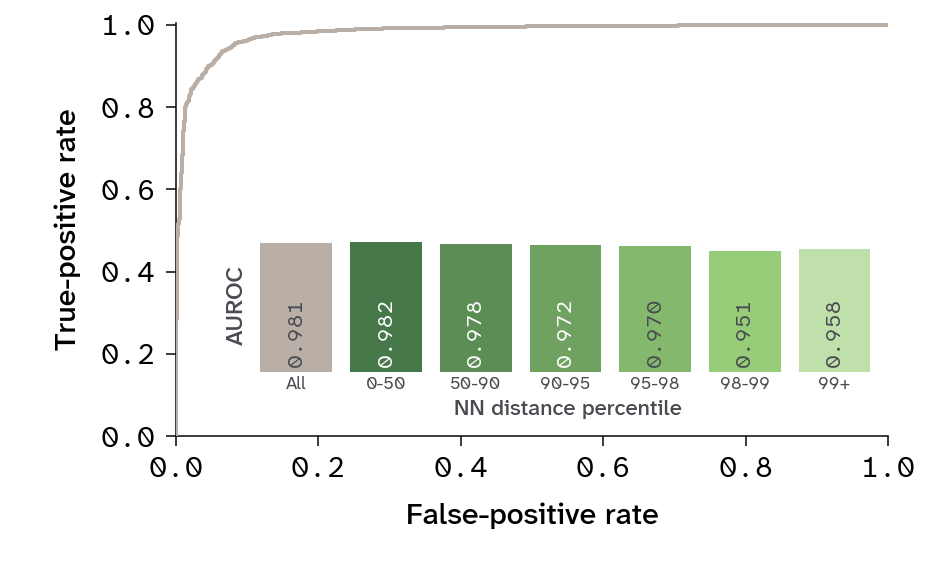

confusion matrix at logit > 0.5 on the 6,000-variant test split [rows = truth, cols = call]:
[[1698  117]
 [ 279 3906]]
  precision 0.9709  recall 0.9333  accuracy 0.9340  false positives 117 of 4,023 calls


In [12]:
# One panel: the pooled held-out ROC, with the campaign's two thresholds marked where they actually
# fall -- a tight cluster against the corner, which is the point, the shortlist bar carrying the
# larger marker because it is the one a design has to clear. The inset is the aggregate's own
# caveat: AUROC inside each stratum of the campaign's distance statistic, so the curve and the
# question "does it hold where the designs sit" are read in one place. Inset bars run from 0.5, the
# floor of the metric, and carry their value, since the whole range they move over is a few points.
from matplotlib.colors import to_rgb  # noqa: E402
from matplotlib.patches import Rectangle  # noqa: E402

r = ROC[DRAWN]

fig, ax = plt.subplots(figsize=(HALF_PANEL * PX, 285 * PX))
fig.subplots_adjust(left=0.185, right=0.935, bottom=0.235, top=0.96)
ax.plot(r["fpr"], r["tpr"], color=r["color"], lw=2, zorder=4)
ax.set(xlim=(0, 1), ylim=(0, 1.005), xlabel="False-positive rate", ylabel="True-positive rate")
apc.mpl.style_plot(ax, monospaced_axes="both")
bare(ax)

# Inset: the drawn curve's own area at the left in the curve's own colour, set apart by a gap, then
# one bar per distance stratum, each carrying its value inside. It has axis titles rather than a
# heading, so it reads as a chart in its own right; an inset inherits this notebook's large rcParams
# text sizes, so every size is set explicitly.
inset = ax.inset_axes([0.10, 0.155, 0.9, 0.325], zorder=7)
inset.set_facecolor("white")
# The inset keeps a ramp of its own: greens, because the subject is
# green fluorescence, running from the dark end at the innermost stratum to the pale end at
# percentile 99+, so the bars fade as the population walks away from the DMS cloud.
INSET_C = [apc.gradients.greens.to_mpl_cmap()(v)      # apc gradients run dark -> light
           for v in np.linspace(0.0, 0.78, len(STRAT_AUROC))]
xs = np.r_[-1, np.arange(len(STRAT_AUROC))]
colors = [r["color"]] + INSET_C
inset.bar(xs, [s["auroc"] for s in INSET_BARS], color=colors, width=0.8, edgecolor="none",
          zorder=3)
for x, s, c in zip(xs, INSET_BARS, colors):
    # The ramp crosses from dark to pale under the numerals, so each is set by the luminance of its
    # own bar: white while the green still carries it, Charcoal once it does not -- which is also
    # what the pale Chateau of the unstratified bar needs.
    lum = float(np.dot(to_rgb(c), (0.299, 0.587, 0.114)))
    inset.annotate(f"{s['auroc']:.3f}", xy=(x, 0.518), rotation=90, ha="center", va="bottom",
                   **{**NUMBER_NOTE, "fontsize": 11,
                      "color": "white" if lum < 0.62 else str(apc.charcoal)})
inset.set_ylim(0.5, 1.0)
inset.set_yticks([])
inset.set_xlim(-1.55, len(STRAT_AUROC) - 0.4)
inset.set_xticks(xs)
inset.set_xticklabels([s["label"] for s in INSET_BARS], fontsize=10)
inset.tick_params(length=0, labelsize=9, colors=str(apc.charcoal), pad=2)
inset.set_xlabel("NN distance percentile", fontsize=11,
                 labelpad=4, color=str(apc.charcoal))
inset.set_ylabel("AUROC", fontsize=12, labelpad=0, color=str(apc.charcoal))
for side in inset.spines.values():
    side.set_visible(False)

fig.savefig(f"{FIGDIR}/brightness_roc_operating_points.svg")
fig.savefig(f"{FIGDIR}/brightness_roc_operating_points.png", dpi=200)
plt.show()

# The operating point as counts, kept as a printout now that the inset carries the strata instead.
yhat = (te.logit > THR_SHORTLIST).astype(int).to_numpy()
ytrue = te.y.to_numpy()
CM = np.array([[int(((ytrue == i) & (yhat == j)).sum()) for j in (0, 1)] for i in (0, 1)])
print(f"confusion matrix at logit > 0.5 on the {len(te):,}-variant test split "
      f"[rows = truth, cols = call]:\n{CM}")
print(f"  precision {CM[1, 1] / CM[:, 1].sum():.4f}  recall {CM[1, 1] / CM[1].sum():.4f}  "
      f"accuracy {(CM[0, 0] + CM[1, 1]) / CM.sum():.4f}  "
      f"false positives {CM[0, 1]:,} of {CM[:, 1].sum():,} calls")


**Figure 3. The classifier's ranking of held-out variants is close to perfect, and it barely weakens
in the sparse corner of the distribution the designs occupy.** ROC on the 6,000 held-out test
variants (Chateau) with the chance diagonal. Inset: AUROC of the same classifier, unstratified at the
left in the curve's own colour — the area of the curve beside it — and then inside each stratum of
the campaign's distance statistic, on the 97,499 never-fitted variants of Section 3, binned by
percentile of the DMS cloud's own self-neighbour distances, on
42,546 / 41,912 / 6,364 / 4,003 / 1,438 / 1,234 variants. The strata carry a greens ramp of their own
that pales as they move outward. Inset bars run from 0.5, the floor of the
metric, and carry their value, because the whole range they cover is three points.

**The campaign never uses most of this curve.** Its two thresholds are points on it, not regions: at
`logit > 0` the model runs at TPR 0.945 / FPR 0.077, and at the shortlist bar `logit > 0.5` at
TPR 0.933 / FPR 0.065 — two points a few hundredths apart, both jammed into the top-left corner, both
printed above rather than marked, since at this panel size two markers that close read as one. The
area summarizes the whole threshold range including the long right-hand stretch where everything is
called bright, which the campaign never enters; everything it does is decided in that corner.

What the corner is worth is a ratio, not an area. **Precision cannot be carried from DMS variants to
designs, and LR+ = TPR / FPR can.** Precision depends on the population's bright rate — 70% in the
test split, unknown and much lower in a pool of 10-substitution pocket designs — so the 97.1% this
model achieves at the shortlist bar is not a prediction about a shortlist. The likelihood ratio is a
property of the classifier at a fixed threshold, so it multiplies whatever the design pool's prior
odds happen to be. Two are printed above: 14.5 over
all held-out variants, and **32.0** over the 914 carrying at least five substitutions — the
design-matched stratum, whose curve is not drawn because it lies on top of this one (areas 0.978
against 0.981) while the number that separates them is invisible as a shape. At higher edit load the
false-positive rate falls faster than the true-positive rate does (0.065 → 0.027 against 0.933 →
0.850), because a heavily mutated variant that is dim is easy to call. One caveat on reading that
2.2x as the classifier being *better* on design-like variants: part of it is threshold drift — harder
populations score lower overall, so a bar fixed at 0.5 sits further out in their score distribution
and trades recall for selectivity.

**The inset is the aggregate's own caveat, and it comes back mild.** An AUROC over all held-out
variants says nothing about whether the ordering survives away from the DMS cloud, which is exactly
where the designs sit. It largely does: 0.981 unstratified, 0.982 in the innermost half of the cloud,
0.972 and 0.970 in the percentile 90-95 and 95-98 bands the in-distribution gate admits designs into,
and 0.951-0.958 in the two outermost strata — a drift of three points across the whole distance
range. The leftmost bar is the test split and the other
six are the wide pool, which is not the easier population: unstratified it scores 0.984. So what
degrades out there is not the ranking but where a fixed bar sits on it — the median logit of a
*bright* variant falls from +5.95 to +1.41, so `logit > 0.5` slides into the tail.

The same operating point in plain counts, printed below: of 6,000 held-out variants — 4,185 truly
bright, 1,815 truly dim — the bar calls 4,023 bright, and 3,906 of those are. So 117 dim variants get
through, and 279 bright ones are thrown away with the 1,698 correctly rejected. Recall being the
cheaper error is why the campaign can afford the stricter bar at all — it throws away thousands of
candidates by construction.